In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("data.csv")

In [4]:
print(df.shape)
df.head()

(42372, 1036)


,CONS_NO,FLAG,2014/1/1,2014/1/10,2014/1/11,2014/1/12,2014/1/13,2014/1/14,2014/1/15,2014/1/16,...,2016/9/28,2016/9/29,2016/9/3,2016/9/30,2016/9/4,2016/9/5,2016/9/6,2016/9/7,2016/9/8,2016/9/9
0,0387DD8A07E07FDA6271170F86AD9151,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.12,9.96,16.92,7.60,27.22,18.05,26.47,18.75,17.84,14.92
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,B32AC8CC6D5D805AC053557AB05F5343,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.50,9.99,11.78,18.59,26.80,18.57,14.59,12.82,19.37,15.92
4,EDFC78B07BA2908B3395C4EB2304665E,1,2.9,3.42,3.81,4.58,3.56,4.25,3.86,3.53,...,17.77,10.37,15.32,13.51,12.23,14.68,16.35,18.14,18.41,17.31


In [5]:
print(df['FLAG'].value_counts())

FLAG
0    38757
1     3615
Name: count, dtype: int64


In [6]:
df.isnull().sum()

CONS_NO          0
FLAG             0
2014/1/1     16502
2014/1/10    16460
2014/1/11    16461
             ...  
2016/9/5       499
2016/9/6       522
2016/9/7       405
2016/9/8       328
2016/9/9       345
Length: 1036, dtype: int64

In [7]:
ids = df['CONS_NO']

In [8]:
df = df.drop("CONS_NO", axis=1)

In [9]:
df = df.ffill(axis=1)
df = df.bfill(axis=1)

In [10]:
df = df.fillna(0)

In [ ]:
# -----------------------------
# Long-term consumption features
# -----------------------------

# Average consumption
df["avg_consumption"] = df.iloc[:, 1:].mean(axis=1)

# Max consumption
df["max_consumption"] = df.iloc[:, 1:].max(axis=1)

# Min consumption
df["min_consumption"] = df.iloc[:, 1:].min(axis=1)

# Standard deviation (usage variation)
df["std_consumption"] = df.iloc[:, 1:].std(axis=1)

# Drop from average (sudden drop detection)
df["drop_from_avg"] = df["avg_consumption"] - df["min_consumption"]

# Consumption ratio
df["consumption_ratio"] = df["min_consumption"] / (df["avg_consumption"] + 0.0001)

# -----------------------------
# Consecutive zero days feature
# -----------------------------
def max_consecutive_zeros(row):
    count = 0
    max_count = 0
    for val in row:
        if val == 0:
            count += 1
            max_count = max(max_count, count)
        else:
            count = 0
    return max_count

df["max_zero_days"] = df.iloc[:, 1:-7].apply(max_consecutive_zeros, axis=1)

print("Long-term features added")

In [11]:
X = df.drop("FLAG", axis=1)
y = df["FLAG"]

In [12]:
X.to_csv("processed_data.csv", index=False) 

In [13]:
X.isnull().sum()

2014/1/1     0
2014/1/10    0
2014/1/11    0
2014/1/12    0
2014/1/13    0
            ..
2016/9/5     0
2016/9/6     0
2016/9/7     0
2016/9/8     0
2016/9/9     0
Length: 1034, dtype: int64

In [14]:
X.dtypes

2014/1/1     float64
2014/1/10    float64
2014/1/11    float64
2014/1/12    float64
2014/1/13    float64
              ...   
2016/9/5     float64
2016/9/6     float64
2016/9/7     float64
2016/9/8     float64
2016/9/9     float64
Length: 1034, dtype: object

In [15]:
y.dtypes

dtype('float64')

In [16]:
X = X.apply(pd.to_numeric, errors='coerce')

In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X_scaled, y, ids, test_size=0.2, random_state=42)

In [19]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

print(y_train.value_counts())

FLAG
0.0    31040
1.0    31040
Name: count, dtype: int64


In [ ]:
print(y.value_counts())

In [ ]:
from sklearn.metrics import accuracy_score

y_prob = model.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.4).astype(int)
print("Accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

In [23]:
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("False Positives:", FP)

Accuracy: 0.9085545722713865
Precision: 0.4921946740128558
Recall: 0.7071240105540897
F1 Score: 0.5804006497022198
False Positives: 553


In [25]:
result = pd.DataFrame({
    'CONS_NO': ids_test.values,
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probability': y_prob
})

theft_consumers = result[result['Predicted'] == 1]

print("Number of theft cases detected:", len(theft_consumers))
print(theft_consumers.head(20))

Number of theft cases detected: 1089
                              CONS_NO  Actual  Predicted  Probability
4    D337C05D2897E43B60968F708203C995     0.0          1         0.51
12   0BA7CEE98CE7EB920FE0E6D8B56FE8FB     1.0          1         0.56
17   A26CBC01005EF5FB1DA977E0ED4630CE     0.0          1         0.42
28   5BE386F490612227759D4A310DF116E4     0.0          1         0.49
31   D0C30EBA8AA8552523A077DF424C0474     0.0          1         0.52
35   09882A7662F9DBDC6A2D0CEDD33B0E93     1.0          1         1.00
46   70AA17144CD1050BB4F53EAAF04A7831     1.0          1         0.78
49   6D3DF25FCB7CB2B773FF3DC985C92B92     0.0          1         0.43
60   B4D7D4383A60B3E4FCC19F33A482C931     0.0          1         0.64
63   D57450BE243504763201DD7A1CF432CC     1.0          1         0.97
64   5CA8A11807180F3C51184288B0C8251C     1.0          1         0.49
67   9D0A0A53A5CB43413FD4FCF324C00B87     1.0          1         0.67
88   9494EF9D4528A088BCD0C75FD1518C74     0.0        

In [26]:
import pandas as pd

metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'False Positives'],
    'Value': [accuracy, precision, recall, f1, FP]
})

metrics.to_csv("model_metrics.csv", index=False)

In [27]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def evaluate_model(model_name, y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    
    TN = cm[0][0]
    FP = cm[0][1]
    FN = cm[1][0]
    TP = cm[1][1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return pd.DataFrame({
        'Model': [model_name],
        'Accuracy': [accuracy],
        'Precision': [precision],
        'Recall': [recall],
        'F1 Score': [f1],
        'TN': [TN],
        'FP': [FP],
        'FN': [FN],
        'TP': [TP]
    })

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

results_table = pd.DataFrame(columns=[
    'Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'Confusion Matrix'
])

In [19]:
def run_model(model, model_name, threshold):
    model.fit(X_train, y_train)
    
    y_prob = model.predict_proba(X_test)[:,1]
    y_pred = (y_prob > threshold).astype(int)
    
    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    global results_table
    results_table.loc[len(results_table)] = [
        model_name, acc, pre, rec, f1, cm
    ]

In [30]:
from sklearn.linear_model import LogisticRegression
run_model(LogisticRegression(max_iter=1000), "Logistic Regression", 0.4)

In [31]:
print(results_table)

                 Model  Accuracy  Precision    Recall  F1 Score  \
0  Logistic Regression  0.122242   0.089266  0.957784  0.163311   

           Confusion Matrix  
0  [[310, 7407], [32, 726]]  


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
     #"Logistic Regression": LogisticRegression(max_iter=1000),
     #"Decision Tree": DecisionTreeClassifier(max_depth=15),
     #"Random Forest": RandomForestClassifier(n_estimators=300, class_weight='balanced'),
    # "KNN": KNeighborsClassifier(n_neighbors=5),
     "SVM": SVC(probability=True),
     #"Naive Bayes": GaussianNB(),
     #"AdaBoost": AdaBoostClassifier(n_estimators=200),
     #"XGBoost": XGBClassifier(n_estimators=400, max_depth=8, learning_rate=0.05, scale_pos_weight=10),
   #"LightGBM": LGBMClassifier(n_estimators=400)
}

In [ ]:
for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    # Predict probabilities
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)
    
    # Threshold tuning
    threshold = 0.4
    if name in ["XGBoost", "LightGBM"]:
        threshold = 0.45
    
    y_pred = (y_prob > threshold).astype(int)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    # Store results
    results_table.loc[len(results_table)] = [name, acc, pre, rec, f1, cm]

# Show results
print(results_table)

In [25]:
import pandas as pd
import os

file_path = "all_model_results.csv"

# If file exists, load it
if os.path.exists(file_path):
    old_results = pd.read_csv(file_path)
    results_table = pd.concat([old_results, results_table], ignore_index=True)

# Save updated results
results_table.to_csv(file_path, index=False)

In [1]:
import pandas as pd

df = pd.read_csv("all_model_results.csv")
print(df)

                   Model  Accuracy  Precision    Recall  F1 Score  \
0                XGBoost  0.910796   0.500923  0.716359  0.589577   
1               AdaBoost  0.305487   0.112923  0.986807  0.202655   
2                XGBoost  0.910796   0.500923  0.716359  0.589577   
3               AdaBoost  0.305487   0.112923  0.986807  0.202655   
4               AdaBoost  0.305487   0.112923  0.986807  0.202655   
..                   ...       ...        ...       ...       ...   
96           Naive Bayes  0.904543   0.387665  0.116095  0.178680   
97         Decision Tree  0.869971   0.372969  0.666227  0.478220   
98   Logistic Regression  0.122242   0.089266  0.957784  0.163311   
99         Random Forest  0.912802   0.508971  0.711082  0.593286   
100                  KNN  0.750442   0.226301  0.740106  0.346617   

                Confusion Matrix  
0    [[7176  541]\n [ 215  543]]  
1    [[1841 5876]\n [  10  748]]  
2    [[7176  541]\n [ 215  543]]  
3    [[1841 5876]\n [  10  748]

In [2]:
best_row = df.sort_values(by="F1 Score", ascending=False).iloc[0]
best_model_name = best_row["Model"]

print("Best Model is:", best_model_name)

Best Model is: LightGBM


In [24]:
from lightgbm import LGBMClassifier
import pickle

lgb_model = LGBMClassifier()
lgb_model.fit(X_train, y_train)

# Save model
pickle.dump(lgb_model, open("best_model.pkl", "wb"))

print("LightGBM model saved")

[LightGBM] [Info] Number of positive: 31040, number of negative: 31040
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.379770 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 263670
[LightGBM] [Info] Number of data points in the train set: 62080, number of used features: 1034
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM model saved


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
import pickle

# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),   # handles preprocessing
    ('model', LGBMClassifier())     # your best model
])

# Train
pipeline.fit(X_train, y_train)

# Save model
pickle.dump(pipeline, open("model.pkl", "wb"))

print("Model saved successfully ✅")

[LightGBM] [Info] Number of positive: 31040, number of negative: 31040
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.826392 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 263670
[LightGBM] [Info] Number of data points in the train set: 62080, number of used features: 1034
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Model saved successfully ✅


In [1]:
import pickle
import pandas as pd

# Load your processed dataset used for training
df = pd.read_csv("processed_data.csv")

# Remove label and ID if present
if "label" in df.columns:
    df = df.drop("label", axis=1)
if "ID" in df.columns:
    df = df.drop("ID", axis=1)

# Save column names
pickle.dump(df.columns.tolist(), open("columns.pkl", "wb"))

print("columns.pkl saved")

columns.pkl saved


/home/user/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


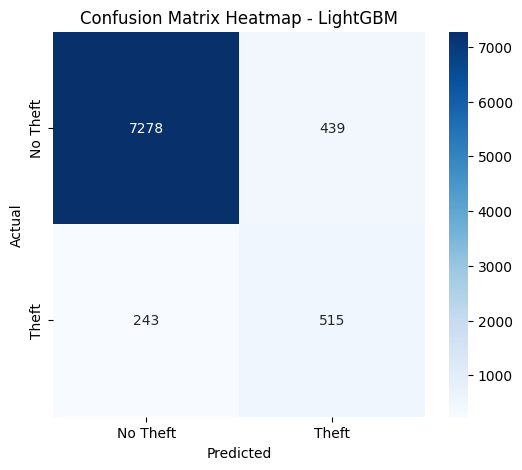

In [20]:
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Load the saved model
lgb_model = pickle.load(open("best_model.pkl", "rb"))

# Predict on test set
y_pred = lgb_model.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Theft', 'Theft'], yticklabels=['No Theft', 'Theft'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap - LightGBM')
plt.show()

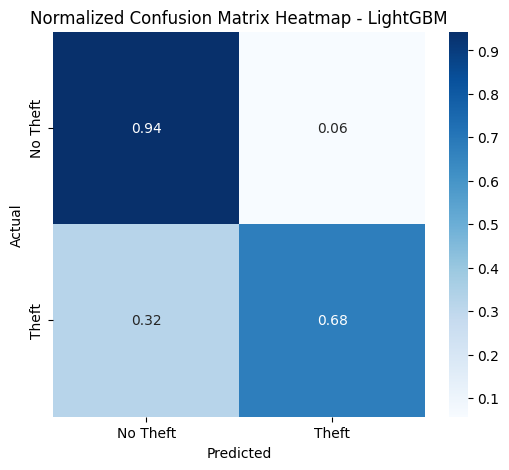

In [21]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6,5))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=['No Theft', 'Theft'], yticklabels=['No Theft', 'Theft'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Normalized Confusion Matrix Heatmap - LightGBM')
plt.show()

<Axes: >

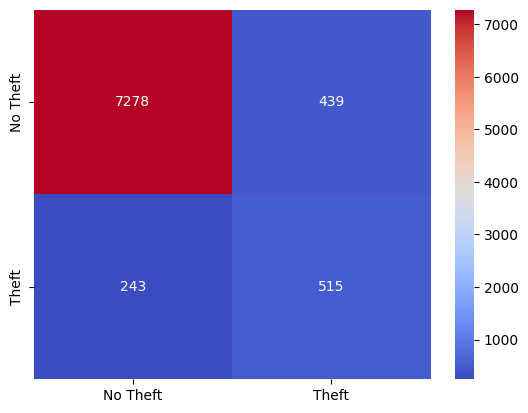

In [22]:
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', xticklabels=['No Theft', 'Theft'], yticklabels=['No Theft', 'Theft'])

In [23]:
plt.savefig('lgbm_confusion_heatmap.png', dpi=300)

<Figure size 640x480 with 0 Axes>

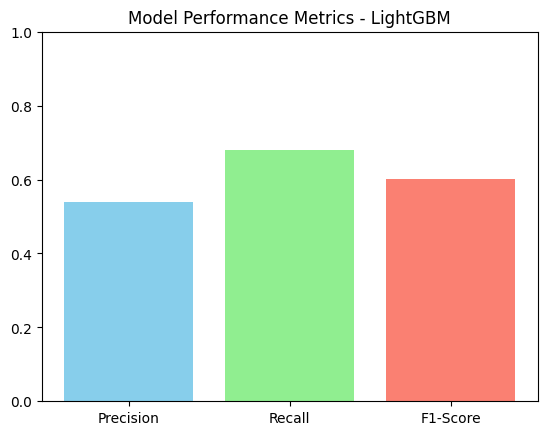

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics = [precision, recall, f1]
names = ['Precision', 'Recall', 'F1-Score']

plt.bar(names, metrics, color=['skyblue', 'lightgreen', 'salmon'])
plt.ylim(0,1)
plt.title('Model Performance Metrics - LightGBM')
plt.show()

/home/user/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


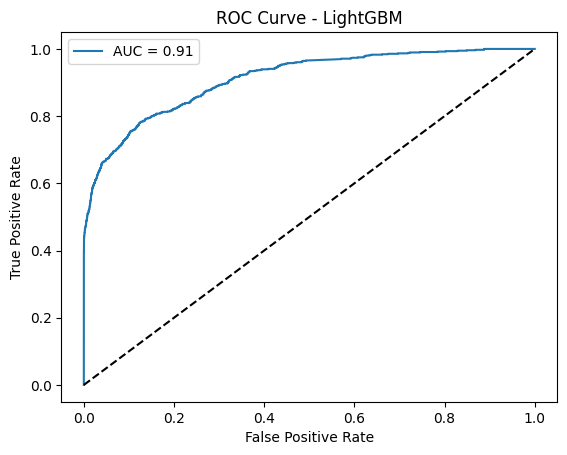

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = lgb_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LightGBM')
plt.legend()
plt.show()

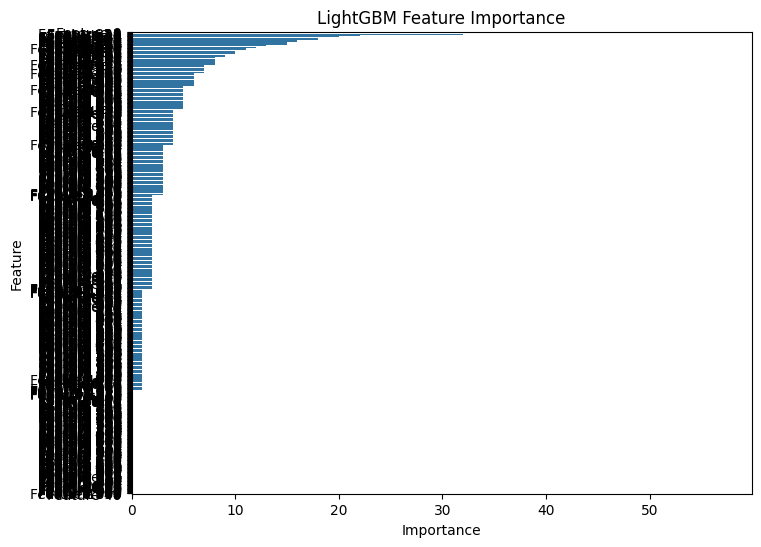

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create generic names
feature_imp = pd.DataFrame({
    'Feature': [f'Feature {i}' for i in range(X_train.shape[1])],
    'Importance': lgb_model.feature_importances_
})
feature_imp = feature_imp.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feature_imp)
plt.title('LightGBM Feature Importance')
plt.show()

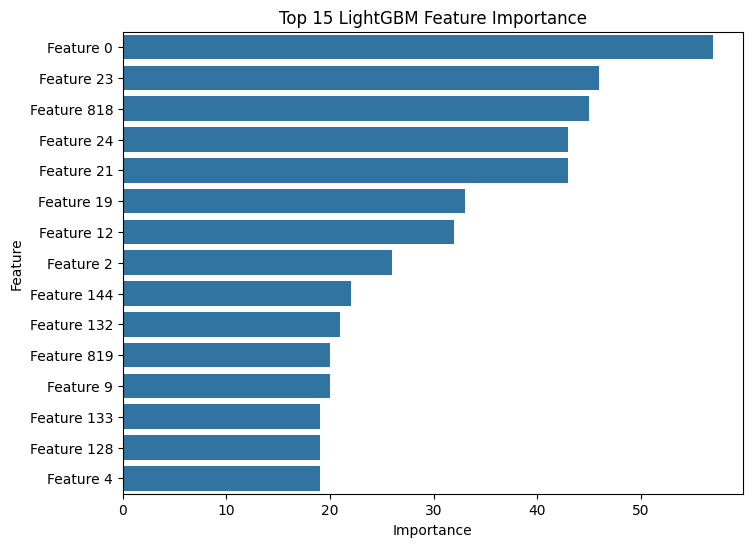

In [29]:
top_n = 15  # show only top 15 features

feature_imp_top = feature_imp.head(top_n)

plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_top)
plt.title('Top 15 LightGBM Feature Importance')
plt.show()

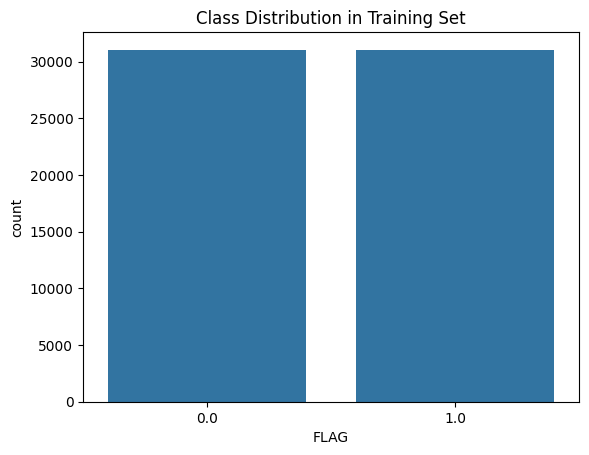

In [27]:
import seaborn as sns
sns.countplot(x=y_train)
plt.title('Class Distribution in Training Set')
plt.show()

/home/user/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


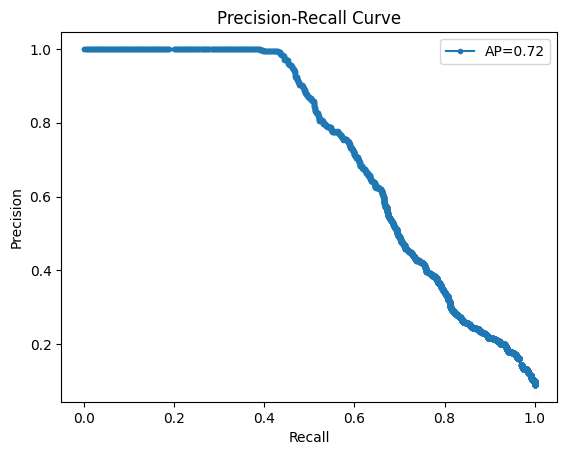

In [30]:
from sklearn.metrics import precision_recall_curve, average_precision_score

y_prob = lgb_model.predict_proba(X_test)[:,1]
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

plt.plot(recall, precision, marker='.', label=f'AP={avg_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

In [31]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(lgb_model, X_train, y_train, cv=5, scoring='f1')
print(f"Mean F1-Score: {scores.mean():.3f} ± {scores.std():.3f}")

[LightGBM] [Info] Number of positive: 24832, number of negative: 24832
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.340075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 263670
[LightGBM] [Info] Number of data points in the train set: 49664, number of used features: 1034
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/home/user/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 24832, number of negative: 24832
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.334400 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 263670
[LightGBM] [Info] Number of data points in the train set: 49664, number of used features: 1034
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/home/user/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 24832, number of negative: 24832
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.359106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 263670
[LightGBM] [Info] Number of data points in the train set: 49664, number of used features: 1034
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/home/user/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 24832, number of negative: 24832
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.329888 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 263670
[LightGBM] [Info] Number of data points in the train set: 49664, number of used features: 1034
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/home/user/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 24832, number of negative: 24832
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.335980 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 263670
[LightGBM] [Info] Number of data points in the train set: 49664, number of used features: 1034
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Mean F1-Score: 0.940 ± 0.018


/home/user/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
